In [2]:
from astropy.io import fits
import pandas as pd

def analyze_fits(file_path):
    print(f"--- 正在分析文件: {file_path} ---\n")
    
    with fits.open(file_path) as hdul:
        # 1. 打印 FITS 文件的总体结构 (HDU 信息)
        print("【1. 文件结构 (HDU List)】")
        hdul.info()
        print("\n")

        for i, hdu in enumerate(hdul):
            print(f"--- 扩展层 (Extension) {i} 详情 ---")
            header = hdu.header
            
            # 2. 识别数据类型 (图像 or 表格)
            if isinstance(hdu, (fits.ImageHDU, fits.PrimaryHDU)) and hdu.data is not None:
                print(f"类型: 图像 (Image)")
                print(f"维度 (Shape): {hdu.data.shape}")
                print(f"数据类型 (Dtype): {hdu.data.dtype}")
                # 打印关键天文坐标信息 (WCS)
                if 'CRVAL1' in header:
                    print(f"参考坐标 (RA, Dec): ({header['CRVAL1']}, {header['CRVAL2']})")
                if 'PHOTZP' in header or 'MAGZERO' in header:
                    zp = header.get('PHOTZP') or header.get('MAGZERO')
                    print(f"测光零点 (Photometric Zeropoint): {zp}")

            elif isinstance(hdu, (fits.BinTableHDU, fits.TableHDU)):
                print(f"类型: 二进制表格 (Binary Table/Catalog)")
                print(f"行数 (Rows): {len(hdu.data)}")
                print(f"列数 (Columns): {len(hdu.columns)}")
                
                # 展示列名，方便确认包含哪些物理量
                col_names = hdu.columns.names
                print(f"列名: {col_names}")
            
            # 如果想看完整的 Header，可以取消下面这行的注释
            # print("\n")
            # print(header)
            print("-" * 40 + "\n")

In [8]:
# 使用
analyze_fits("../data_Clauds/COSMOS-HSCpipe-Phosphoros.fits")

--- 正在分析文件: ../data_Clauds/COSMOS-HSCpipe-Phosphoros.fits ---

【1. 文件结构 (HDU List)】
Filename: ../data_Clauds/COSMOS-HSCpipe-Phosphoros.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  /Users/desprez/CLAUDS/DR2/combCats/COSMOS-HSCpipe.fits#1    1 BinTableHDU    483   5474883R x 235C   [K, D, D, 5A, 3A, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, L, 7L, I, L, L, L, L, L, D, L

In [9]:
analyze_fits("../data_Clauds/XMMLSS-HSCpipe-Phosphoros.fits")

--- 正在分析文件: ../data_Clauds/XMMLSS-HSCpipe-Phosphoros.fits ---

【1. 文件结构 (HDU List)】
Filename: ../data_Clauds/XMMLSS-HSCpipe-Phosphoros.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  /Volumes/Magmar/CLAUDS-HSC/catalogs/DR2_CLAUDS/XMM-LSS-HSCpipe.fi...    1 BinTableHDU    483   5310123R x 235C   [K, D, D, 4A, 3A, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, E, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, D, D, D, D, D, D, D, D, D, D, D, L, L, L, L, L, L, L, L, 7L, I, L, L, L

In [3]:
analyze_fits("../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits")

--- 正在分析文件: ../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits ---

【1. 文件结构 (HDU List)】
Filename: ../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (4834,)   uint8   
  1  /home/desprezg/ownCloud/CLAUDS/COSMOS_v11_6bands_v220127.fits#1    1 BinTableHDU    202   5263013R x 90C   [K, D, D, K, 3A, I, I, E, E, E, E, E, E, D, E, E, E, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, D, E, E, E, D, D, D, I, I, I, E, E, E, E, E, D, K, K, K, L, 7L, E]   


--- 扩展层 (Extension) 0 详情 ---
类型: 图像 (Image)
维度 (Shape): (4834,)
数据类型 (Dtype): uint8
----------------------------------------

--- 扩展层 (Extension) 1 详情 ---
类型: 二进制表格 (Binary Table/Catalog)
行数 (Rows): 5263013
列数 (Columns): 90
列名: ['ID', 'RA', 'DEC', 'TRACT', 'PATCH', 'MASK', 'FLAG_FIELD', 'A_WORLD', 'B_WORLD', 'KRON_RADIUS', 'THETA_W

In [4]:
analyze_fits("../data_Clauds/XMMLSS_6bands-SExtractor-Lephare.fits")

--- 正在分析文件: ../data_Clauds/XMMLSS_6bands-SExtractor-Lephare.fits ---

【1. 文件结构 (HDU List)】
Filename: ../data_Clauds/XMMLSS_6bands-SExtractor-Lephare.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (4840,)   uint8   
  1  /home/desprezg/ownCloud/CLAUDS/XMM_LSS_v11_6bands_v220127.fits#1    1 BinTableHDU    202   5166244R x 90C   [K, D, D, K, 3A, I, I, E, E, E, E, E, E, D, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, D, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, D, E, E, E, D, D, D, I, I, I, E, E, E, E, E, D, K, K, K, L, 7L, E]   


--- 扩展层 (Extension) 0 详情 ---
类型: 图像 (Image)
维度 (Shape): (4840,)
数据类型 (Dtype): uint8
----------------------------------------

--- 扩展层 (Extension) 1 详情 ---
类型: 二进制表格 (Binary Table/Catalog)
行数 (Rows): 5166244
列数 (Columns): 90
列名: ['ID', 'RA', 'DEC', 'TRACT', 'PATCH', 'MASK', 'FLAG_FIELD', 'A_WORLD', 'B_WORLD', 'KRON_RADIUS', 'THETA_

In [2]:
analyze_fits("../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits")

--- 正在分析文件: ../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits ---

【1. 文件结构 (HDU List)】
Filename: ../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SPECINFO      1 BinTableHDU    286   4486R x 103C   [K, J, D, D, 22A, E, E, E, K, B, 3A, D, J, E, K, K, K, K, K, K, K, K, K, D, D, I, E, I, I, E, E, E, E, E, D, E, D, E, D, D, D, K, 108A, K, 10A, 209A, E, E, L, L, L, 30A, 100A, L, L, L, E, E, 10A, 450A, D, D, K, D, 10D, 4A, K, 6A, 20A, K, D, 9D, 54A, 9D, 120A, D, L, D, D, D, D, D, D, D, D, L, D, D, D, D, D, D, D, D, L, D, D, D, D, D, D, D, D]   


--- 扩展层 (Extension) 0 详情 ---
----------------------------------------

--- 扩展层 (Extension) 1 详情 ---
类型: 二进制表格 (Binary Table/Catalog)
行数 (Rows): 4486
列数 (Columns): 103
列名: ['TARGETID', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'DESINAME', 'PMRA', 'PMDEC', 'REF_EPOCH', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'SUBPRIORITY', 'OBSCONDITIONS', 

In [3]:
analyze_fits("../CLAUDS_udrop_specz/COSMOS_udrop.fits")

--- 正在分析文件: ../CLAUDS_udrop_specz/COSMOS_udrop.fits ---

【1. 文件结构 (HDU List)】
Filename: ../CLAUDS_udrop_specz/COSMOS_udrop.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  Joined        1 BinTableHDU     24   14091R x 6C   [D, D, E, E, E, L]   


--- 扩展层 (Extension) 0 详情 ---
----------------------------------------

--- 扩展层 (Extension) 1 详情 ---
类型: 二进制表格 (Binary Table/Catalog)
行数 (Rows): 14091
列数 (Columns): 6
列名: ['RA', 'DEC', 'PMRA', 'PMDEC', 'REF_EPOCH', 'OVERRIDE']
----------------------------------------



In [4]:
analyze_fits("../CLAUDS_udrop_specz/XMM_udrop_specz.fits")

--- 正在分析文件: ../CLAUDS_udrop_specz/XMM_udrop_specz.fits ---

【1. 文件结构 (HDU List)】
Filename: ../CLAUDS_udrop_specz/XMM_udrop_specz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SPECINFO      1 BinTableHDU    286   6386R x 103C   [K, J, D, D, 22A, E, E, E, K, B, 3A, D, J, E, K, K, K, K, K, K, K, K, K, D, D, I, E, I, I, E, E, E, E, E, D, E, D, E, D, D, D, K, 108A, K, 10A, 209A, E, E, L, L, L, 30A, 100A, L, L, L, E, E, 10A, 450A, D, D, K, D, 10D, 4A, K, 6A, 20A, K, D, 9D, 54A, 9D, 120A, D, L, D, D, D, D, D, D, D, D, L, D, D, D, D, D, D, D, D, L, D, D, D, D, D, D, D, D]   


--- 扩展层 (Extension) 0 详情 ---
----------------------------------------

--- 扩展层 (Extension) 1 详情 ---
类型: 二进制表格 (Binary Table/Catalog)
行数 (Rows): 6386
列数 (Columns): 103
列名: ['TARGETID', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'DESINAME', 'PMRA', 'PMDEC', 'REF_EPOCH', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'SUBPRIORITY', 'OBSCONDITIONS', 'EBV',

In [5]:
analyze_fits("../CLAUDS_udrop_specz/XMM_udrop.fits")

--- 正在分析文件: ../CLAUDS_udrop_specz/XMM_udrop.fits ---

【1. 文件结构 (HDU List)】
Filename: ../CLAUDS_udrop_specz/XMM_udrop.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  XMM_LSS_v10_v210913_withGALEX.fits#1    1 BinTableHDU    460   11664R x 214C   [K, D, D, K, 3A, I, I, 7L, E, E, E, E, E, E, D, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, K, K, K, D, D, D, D, D, D, D, K, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, D, D, D, D, D, D, D, D, D, D, K, K, K, K, L, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, L, L, L]   


--- 扩展层 (Extension) 0 详情 ---
--

Now we extract ID in XMM dataset and validate the flux ratio to magnitude conversion.


Processing: XMM-LSS

[XMM-LSS] Step 1: Loading Data Files...
✓ Selected catalog:  11664 rows
  Path: ../CLAUDS_udrop_specz/XMM_udrop.fits
✓ Raw CLAUDS catalog: 5310123 rows
  Path: ../data_Clauds/XMMLSS-HSCpipe-Phosphoros.fits

[XMM-LSS] Step 2: Detecting Coordinate Columns...
----------------------------------------
  [Selected] Auto-detected:  RA='RA', DEC='DEC'
  [Raw] Auto-detected: RA='RA', DEC='DEC'

[XMM-LSS] Step 3: Coordinate Preview
----------------------------------------

【Selected】前3行 (RA, DEC):
  Row 0: RA=36.179076, DEC=-5.942716
  Row 1: RA=36.141444, DEC=-5.941938
  Row 2: RA=36.185576, DEC=-5.929071

【Raw】前3行 (RA, DEC):
  Row 0: RA=36.333296, DEC=-6.052684
  Row 1: RA=36.320414, DEC=-6.052393
  Row 2: RA=36.332477, DEC=-6.051942

[XMM-LSS] Step 4: Coordinate Matching...
----------------------------------------
  Selected coordinates:  11664
  Raw coordinates: 5310123

  Matching...
  ✓ Matching complete!

[XMM-LSS] Step 5: Matching Results Analysis
------------------

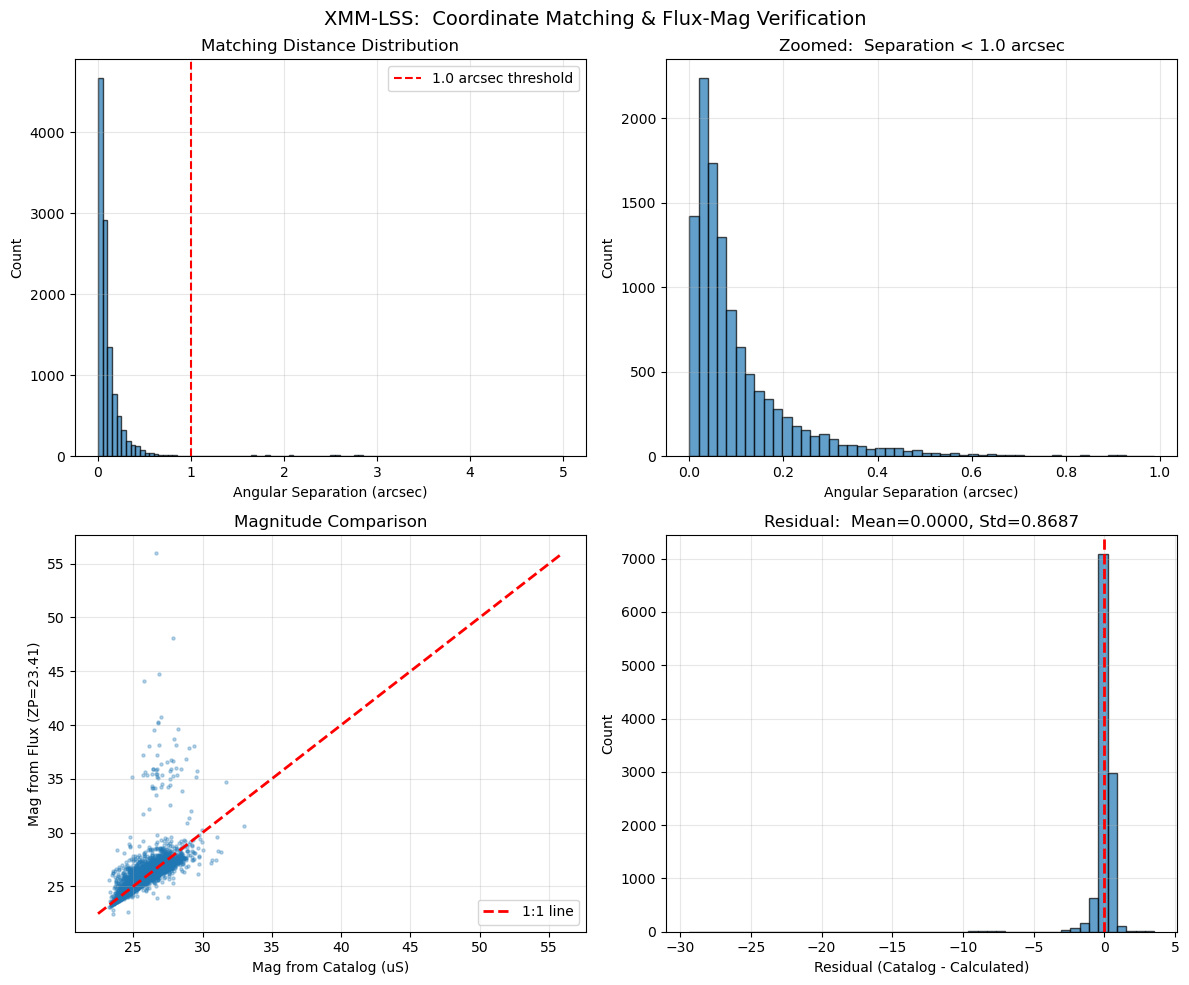


[XMM-LSS] Summary

  1. 坐标列: 
     - Selected: (RA, DEC)
     - Raw: (RA, DEC)
     
  2. 坐标匹配结果: 
     - 总源数: 11664
     - < 1.0 arcsec 匹配:  11243 (96.4%)
     
  3.  Flux -> Mag 转换公式:
     m = 23.41 - 2.5 * log10(Flux)
     ZP Std:  0.8687


Processing: COSMOS

[COSMOS] Step 1: Loading Data Files...
✓ Selected catalog:  14091 rows
  Path: ../CLAUDS_udrop_specz/COSMOS_udrop.fits
✓ Raw CLAUDS catalog: 5474883 rows
  Path: ../data_Clauds/COSMOS-HSCpipe-Phosphoros.fits

[COSMOS] Step 2: Detecting Coordinate Columns...
----------------------------------------
  [Selected] Auto-detected:  RA='RA', DEC='DEC'
  [Raw] Auto-detected: RA='RA', DEC='DEC'

[COSMOS] Step 3: Coordinate Preview
----------------------------------------

【Selected】前3行 (RA, DEC):
  Row 0: RA=149.461763, DEC=2.990385
  Row 1: RA=149.375268, DEC=2.955689
  Row 2: RA=149.372508, DEC=3.080248

【Raw】前3行 (RA, DEC):
  Row 0: RA=148.845916, DEC=0.700320
  Row 1: RA=148.831295, DEC=0.700906
  Row 2: RA=148.825983, DEC=0.701231

In [1]:
from utils.coordinate_matching_utils import batch_verify

configs = [
    {
        'path_selected': "../CLAUDS_udrop_specz/XMM_udrop.fits",
        'path_raw': "../data_Clauds/XMMLSS-HSCpipe-Phosphoros.fits",
        'field_name': "XMM-LSS"
    },
    {
        'path_selected': "../CLAUDS_udrop_specz/COSMOS_udrop.fits",
        'path_raw':  "../data_Clauds/COSMOS-HSCpipe-Phosphoros.fits",
        'field_name': "COSMOS"
    }
]

all_results = batch_verify(configs, match_radius=1.0, save_plots=False)

In [2]:
from utils.coordinate_matching_utils import batch_verify

configs = [
    {
        'path_selected': "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits",
        'path_raw': "../CLAUDS_udrop_specz/COSMOS_udrop.fits",
        'field_name': "XMM-LSS"
    },
    {
        'path_selected': "../CLAUDS_udrop_specz/XMM_udrop_specz.fits",
        'path_raw':  "../CLAUDS_udrop_specz/XMM_udrop.fits",
        'field_name': "COSMOS"
    }
]

all_results = batch_verify(configs, match_radius=1.0, save_plots=False)


Processing: XMM-LSS

[XMM-LSS] Step 1: Loading Data Files...
✓ Selected catalog:  4486 rows
  Path: ../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits
✓ Raw CLAUDS catalog: 14091 rows
  Path: ../CLAUDS_udrop_specz/COSMOS_udrop.fits

[XMM-LSS] Step 2: Detecting Coordinate Columns...
----------------------------------------
  [Selected] Auto-detected:  RA='TARGET_RA', DEC='TARGET_DEC'
  [Raw] Auto-detected: RA='RA', DEC='DEC'

[XMM-LSS] Step 3: Coordinate Preview
----------------------------------------

【Selected】前3行 (TARGET_RA, TARGET_DEC):
  Row 0: RA=150.386174, DEC=1.018215
  Row 1: RA=150.337356, DEC=1.026364
  Row 2: RA=150.408661, DEC=1.057914

【Raw】前3行 (RA, DEC):
  Row 0: RA=149.461763, DEC=2.990385
  Row 1: RA=149.375268, DEC=2.955689
  Row 2: RA=149.372508, DEC=3.080248

[XMM-LSS] Step 4: Coordinate Matching...
----------------------------------------
  Selected coordinates:  4486
  Raw coordinates: 14091

  Matching...
  ✓ Matching complete!

[XMM-LSS] Step 5: Matching Results An

In [3]:
configs = [
    {
        'path_selected': "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits",
        'path_raw': "../data_Clauds/COSMOS-HSCpipe-Phosphoros.fits",
        'field_name': "COSMOS"
    },
    {
        'path_selected': "../CLAUDS_udrop_specz/XMM_udrop_specz.fits",
        'path_raw':  "../data_Clauds/XMMLSS-HSCpipe-Phosphoros.fits",
        'field_name': "XMM-LSS"
    }
]

all_results = batch_verify(configs, match_radius=1.0, save_plots=False)


Processing: COSMOS

[COSMOS] Step 1: Loading Data Files...
✓ Selected catalog:  4486 rows
  Path: ../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits
✓ Raw CLAUDS catalog: 5474883 rows
  Path: ../data_Clauds/COSMOS-HSCpipe-Phosphoros.fits

[COSMOS] Step 2: Detecting Coordinate Columns...
----------------------------------------
  [Selected] Auto-detected:  RA='TARGET_RA', DEC='TARGET_DEC'
  [Raw] Auto-detected: RA='RA', DEC='DEC'

[COSMOS] Step 3: Coordinate Preview
----------------------------------------

【Selected】前3行 (TARGET_RA, TARGET_DEC):
  Row 0: RA=150.386174, DEC=1.018215
  Row 1: RA=150.337356, DEC=1.026364
  Row 2: RA=150.408661, DEC=1.057914

【Raw】前3行 (RA, DEC):
  Row 0: RA=148.845916, DEC=0.700320
  Row 1: RA=148.831295, DEC=0.700906
  Row 2: RA=148.825983, DEC=0.701231

[COSMOS] Step 4: Coordinate Matching...
----------------------------------------
  Selected coordinates:  4486
  Raw coordinates: 5474883

  Matching...
  ✓ Matching complete!

[COSMOS] Step 5: Matching Result

In [5]:
from utils.lbg_selection_utils import select_lbg_from_specz

result = select_lbg_from_specz(
    "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits",
    z_threshold=2.0,
    vi_quality_min=2.5,
    rr_deltachi2_min=9.0
)

# 获取 LBG 表格
lbg_table = result['lbg_table']
print(f"Found {len(lbg_table)} LBGs")

# 获取非 LBG (低红移 contaminants)
non_lbg_table = result['non_lbg_table']

Loading:  ../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits
Total sources: 4486

LBG Selection Summary

  筛选条件:
    - z > 2.0
    - VI_QUALITY >= 2.5 OR RR_DELTACHI2 > 9.0

  结果统计:
    - 总源数:                 4486
    - VI 质量合格:            1165
    - RR 质量合格:            3002
    - 可靠红移 (VI|RR):      3348
    - LBG (VI):              1046
    - LBG (RR):              1179
    - LBG 总数:              1688 (37.6%)
    - 非 LBG (低红移):       1653
Found 1688 LBGs


In [4]:
from utils.lbg_selection_utils import select_lbg_from_specz, summarize_lbg_selection

files = {
    'COSMOS':  "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits",
    'XMM-LSS':  "../CLAUDS_udrop_specz/XMM_udrop_specz.fits"
}

all_results = {}
for field, path in files.items():
    all_results[field] = select_lbg_from_specz(path, verbose=False)

# 打印汇总表
summarize_lbg_selection(all_results)


LBG SELECTION SUMMARY (ALL FIELDS)

Field           |    Total |   Reliable |      LBG |    Non-LBG |    LBG %
----------------------------------------------------------------------
COSMOS          |     4486 |       3348 |     1688 |       1653 |    37.6%
XMM-LSS         |     6386 |       2119 |     1357 |        749 |    21.2%
----------------------------------------------------------------------
TOTAL           |    10872 |          - |     3045 |       2402 |    28.0%


In [6]:
from utils.lbg_selection_utils import select_lbg_from_specz, get_training_labels

result = select_lbg_from_specz("../CLAUDS_udrop_specz/XMM_udrop_specz.fits")

# 获取二分类标签 (0/1)
labels, z_values = get_training_labels(result, label_type='binary')
print(f"Positive samples (LBG): {sum(labels)}")
print(f"Negative samples:  {len(labels) - sum(labels)}")

Loading:  ../CLAUDS_udrop_specz/XMM_udrop_specz.fits
Total sources: 6386

LBG Selection Summary

  筛选条件:
    - z > 2.0
    - VI_QUALITY >= 2.5 OR RR_DELTACHI2 > 9.0

  结果统计:
    - 总源数:                 6386
    - VI 质量合格:             331
    - RR 质量合格:            1966
    - 可靠红移 (VI|RR):      2119
    - LBG (VI):               317
    - LBG (RR):              1171
    - LBG 总数:              1357 (21.2%)
    - 非 LBG (低红移):        749
Positive samples (LBG): 1357
Negative samples:  5029


In [1]:
from utils.lbg_selection_utils import (
    select_lbg_from_specz, 
    get_training_samples,
    prepare_training_data_from_multiple_fields,
    summarize_lbg_selection
)

# Step 1: 筛选 LBG
files = {
    'COSMOS': "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits",
    'XMM-LSS': "../CLAUDS_udrop_specz/XMM_udrop_specz.fits"
}

all_results = {}
for field, path in files.items():
    all_results[field] = select_lbg_from_specz(path, verbose=False)

summarize_lbg_selection(all_results)

# Step 2: 准备训练数据 (只用可靠红移)
# 方案 A: 混合所有天区
data = prepare_training_data_from_multiple_fields(
    all_results, 
    only_reliable=True,
    test_field=None  # 不单独留出测试集，后续用 train_test_split
)

# 方案 B: 留出 XMM-LSS 作为独立测试集 (测试泛化能力)
data_B = prepare_training_data_from_multiple_fields(
    all_results,
    only_reliable=True, 
    test_field='XMM-LSS'
)

print(f"Training samples: {len(data['train_labels'])}")
print(f"Test samples: {len(data['test_labels']) if data['test_labels'] is not None else 'N/A'}")


LBG SELECTION SUMMARY (ALL FIELDS)

Field           |    Total |   Reliable |      LBG |    Non-LBG |    LBG %
----------------------------------------------------------------------
COSMOS          |     4486 |       3348 |     1688 |       1653 |    37.6%
XMM-LSS         |     6386 |       2119 |     1357 |        749 |    21.2%
----------------------------------------------------------------------
TOTAL           |    10872 |          - |     3045 |       2402 |    28.0%

Multi-Field Training Data Summary

  Training set:
    - Total:    5447
    - Positive: 3045 (55.9%)
    - Negative: 2402

Multi-Field Training Data Summary

  Training set:
    - Total:    3341
    - Positive: 1688 (50.5%)
    - Negative: 1653

  Test set (XMM-LSS):
    - Total:    2106
    - Positive: 1357 (64.4%)
    - Negative:  749
Training samples: 5447
Test samples: N/A


In [2]:
from utils.coordinate_matching_utils import batch_verify

configs = [
    {
        'path_selected': "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits",
        'path_raw': "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits",
        'field_name': "COSMOS"
    },
    {
        'path_selected': "../CLAUDS_udrop_specz/XMM_udrop_specz.fits",
        'path_raw':  "../data_Clauds/XMMLSS_6bands-SExtractor-Lephare.fits",
        'field_name': "XMM-LSS"
    }
]

all_results = batch_verify(configs, match_radius=1.0, save_plots=False)


Processing: COSMOS

[COSMOS] Step 1: Loading Data Files...
✓ Selected catalog:  4486 rows
  Path: ../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits
✓ Raw CLAUDS catalog: 5263013 rows
  Path: ../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits

[COSMOS] Step 2: Detecting Coordinate Columns...
----------------------------------------
  [Selected] Auto-detected:  RA='TARGET_RA', DEC='TARGET_DEC'
  [Raw] Auto-detected: RA='RA', DEC='DEC'

[COSMOS] Step 3: Coordinate Preview
----------------------------------------

【Selected】前3行 (TARGET_RA, TARGET_DEC):
  Row 0: RA=150.386174, DEC=1.018215
  Row 1: RA=150.337356, DEC=1.026364
  Row 2: RA=150.408661, DEC=1.057914

【Raw】前3行 (RA, DEC):
  Row 0: RA=149.410774, DEC=2.883768
  Row 1: RA=149.500440, DEC=2.883560
  Row 2: RA=149.477779, DEC=2.883536

[COSMOS] Step 4: Coordinate Matching...
----------------------------------------
  Selected coordinates:  4486
  Raw coordinates: 5263013

  Matching...
  ✓ Matching complete!

[COSMOS] Step 5: Matching